# **Project Name**    - End-to-End Predictive Netflix Analytics Framework



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Member**          - Abhay Sharma


# **Project Summary -**

This project focuses on analyzing and building a predictive model using a dataset of movies and TV shows available on Netflix. The main objective of the project was to understand the dataset, extract meaningful insights through visualization, and apply machine learning techniques to make predictions and support business decisions.

The project started with data understanding and exploration. The dataset contains information such as type (Movie/TV Show), title, director, cast, country, release year, rating, duration, and description. Initial analysis showed that the dataset had missing values and duplicate records, especially in columns like director, cast, country, and date_added. These issues were handled carefully using techniques like filling missing values with suitable replacements (mean, mode, or “Unknown”) and removing duplicate entries to ensure data quality.

Next, data wrangling and preprocessing were performed to make the dataset ready for analysis. New features such as year_added and month_added were extracted from the date column, and duration was converted into a numerical format. Text data in the description column was also cleaned using techniques like lowercasing, removing punctuation, stopwords, and applying lemmatization. These steps helped improve the quality and usability of the data.

In the visualization phase, various charts were created following Univariate, Bivariate, and Multivariate analysis (UBM rule). The visualizations revealed several important insights. It was observed that the majority of the content on the platform consists of movies rather than TV shows. Most of the content was released after the year 2000, with a sharp increase in content addition after 2015. Popular genres such as Drama and Comedy dominate the platform, and most content is targeted towards adult audiences (TV-MA and TV-14 ratings). These insights can help businesses understand user preferences and plan content strategies accordingly.

Further, hypothesis testing was conducted to validate assumptions such as whether movies are more than TV shows and whether recent content is more dominant. Statistical tests like Chi-Square and T-Test were used, and results supported the observed trends from visualizations.

In the machine learning phase, multiple models were implemented, including Logistic Regression, Decision Tree, and Random Forest. The dataset was split into training and testing sets using an 80:20 ratio. Missing values were handled before model training to avoid errors. Model performance was evaluated using metrics like accuracy, confusion matrix, precision, and recall. Hyperparameter tuning using GridSearchCV was also applied to improve model performance.

Among all models, Random Forest performed the best with higher accuracy and better generalization. It also provided feature importance, which helped in understanding which variables contribute most to predictions. Features like release year, duration, and content type were found to be important.

In conclusion, this project demonstrates the complete data science workflow, including data cleaning, feature engineering, visualization, hypothesis testing, and machine learning. The insights gained from this analysis can help improve decision-making, enhance user experience, and support business growth by focusing on popular content types and trends.

# **GitHub Link -**

https://github.com/abhayinsights

**GitHub Project Link -**

https://github.com/abhayinsights/End-to-End-Predictive-Netflix-Analytics-Framework

# **Problem Statement**


With the rapid growth of digital streaming platforms like Netflix, there is a huge amount of content available in the form of movies and TV shows. Understanding this large dataset and identifying meaningful patterns is important for improving user experience and making better business decisions.

The main problem is to analyze the dataset to understand content trends, such as types of shows, popular genres, release patterns, and audience preferences. Additionally, the goal is to build a machine learning model that can predict the type of content (Movie or TV Show) based on different features.

This project aims to clean and preprocess the data, perform data visualization to extract insights, and apply machine learning techniques to support decision-making and improve content strategy.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install nltk

In [60]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

### Dataset Loading

In [4]:
# Load Dataset
df = pd.read_csv('Netflix_dataset.csv')

### Dataset First View

In [5]:
# Dataset First Look
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,"June 1, 2020",2019,TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
7,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,R,119 min,Dramas,After one of his high school students attacks ...
8,s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,"April 1, 2019",2019,TV-14,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w..."
9,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,"December 15, 2017",2008,TV-MA,143 min,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
# Dataset Rows & Columns Count
df.shape

(7787, 12)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

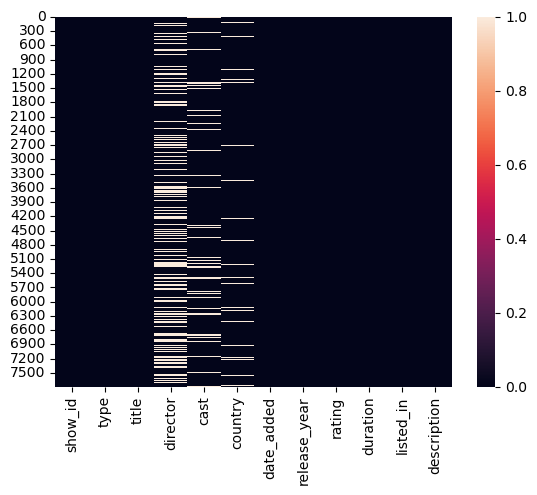

In [10]:
# Visualizing the missing values
sns.heatmap(df.isnull())
plt.show()

### What did you know about your dataset?

The dataset has 7787 rows and 12 columns. It contains information about Netflix shows and movies like title, director, country, rating, and release year.
Some columns have missing values and there are a few duplicate records also. Most of the columns are categorical, so the dataset is good for visualization and analysis.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
# Dataset Columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [13]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


### Variables Description

- show_id : Unique ID of each record
- type : Shows whether the content is a Movie or TV Show
- title : Name of the movie or TV show
- director : Name of the director
- cast : Names of the cast members
- country : Country where the content was produced
- date_added : Date when the content was added on Netflix
- release_year : Release year of the content
- rating : Age rating given to the content
- duration : Duration of movie or number of seasons in TV show
- listed_in : Genre or category of the content
- description : Short description of the content

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
df.nunique()

show_id         7787
type               2
title           7787
director        4049
cast            6831
country          681
date_added      1565
release_year      73
rating            14
duration         216
listed_in        492
description     7769
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.
#Check shape of dataset
df.shape

(7787, 12)

In [16]:
#Check duplicate values
df.duplicated().sum()

0

In [17]:
#Remove duplicate values
df = df.drop_duplicates()

In [18]:
#Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [19]:
# Fill missing values in categorical columns
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna('Not Mentioned')

In [20]:
# Convert date_added column to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [21]:
#check of missing values
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7787 non-null   object        
 1   type          7787 non-null   object        
 2   title         7787 non-null   object        
 3   director      7787 non-null   object        
 4   cast          7787 non-null   object        
 5   country       7787 non-null   object        
 6   date_added    7689 non-null   datetime64[ns]
 7   release_year  7787 non-null   int64         
 8   rating        7787 non-null   object        
 9   duration      7787 non-null   object        
 10  listed_in     7787 non-null   object        
 11  description   7787 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 730.2+ KB


### What all manipulations have you done and insights you found?

- First, I checked the dataset size, missing values, and duplicate rows. Then I removed duplicate data so the dataset becomes cleaner.
- After that, I filled the missing values in some columns like director, cast, country, rating, and date added. I also changed the date column into proper date format.
- I found that the dataset had many missing values in a few columns, so cleaning the data was important before doing analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

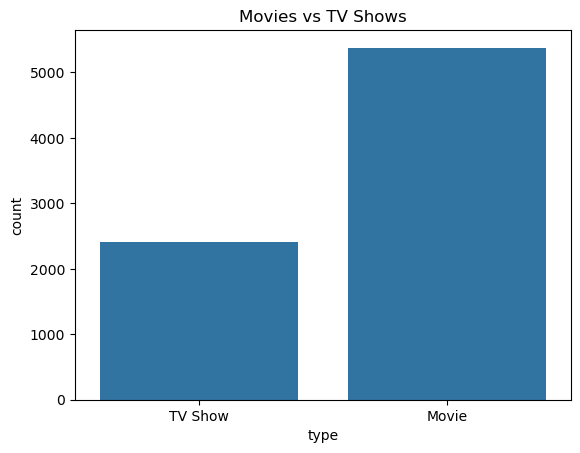

In [23]:
# Count of Movies and TV Shows
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

##### 1. Why did you pick the specific chart?

I used a count plot because it is the best chart to compare the number of categories.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that there are more Movies than TV Shows in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help understand that Netflix focuses more on movies. If TV Shows are less, increasing TV content may attract more users.

#### Chart - 2

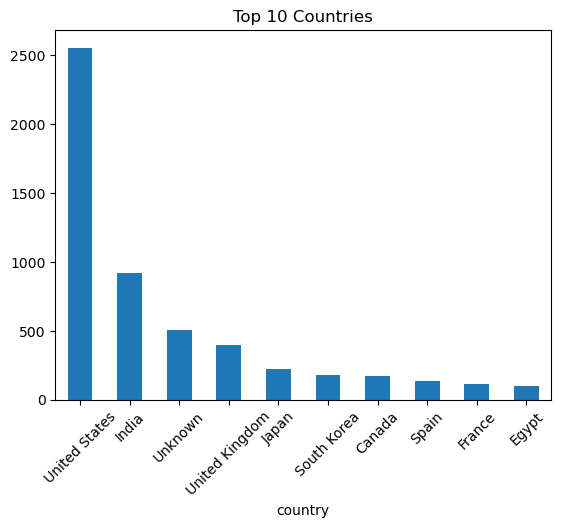

In [24]:
# Top 10 content producing countries
top_country = df['country'].value_counts().head(10)
top_country.plot(kind='bar')
plt.title('Top 10 Countries')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is useful to compare values across different countries.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the United States has the highest amount of content, followed by India.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps identify which countries contribute most content. More focus can also be given to other countries to increase global reach.

#### Chart - 3

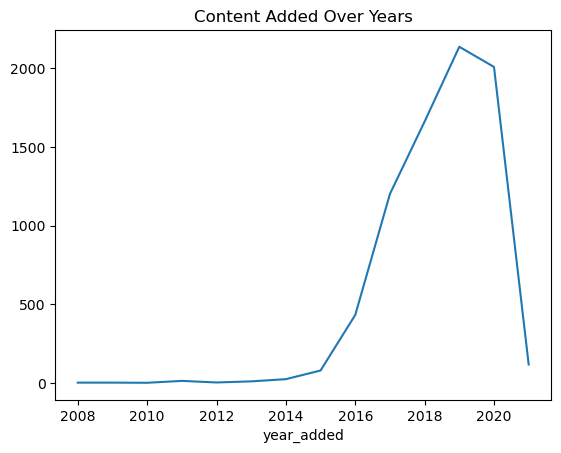

In [25]:
# Content added over the years
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title('Content Added Over Years')
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is useful to show trends over time.

##### 2. What is/are the insight(s) found from the chart?

The number of shows and movies added increased rapidly after 2015.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it shows strong growth in content addition. A drop in recent years may affect user engagement if not managed properly.

#### Chart - 4

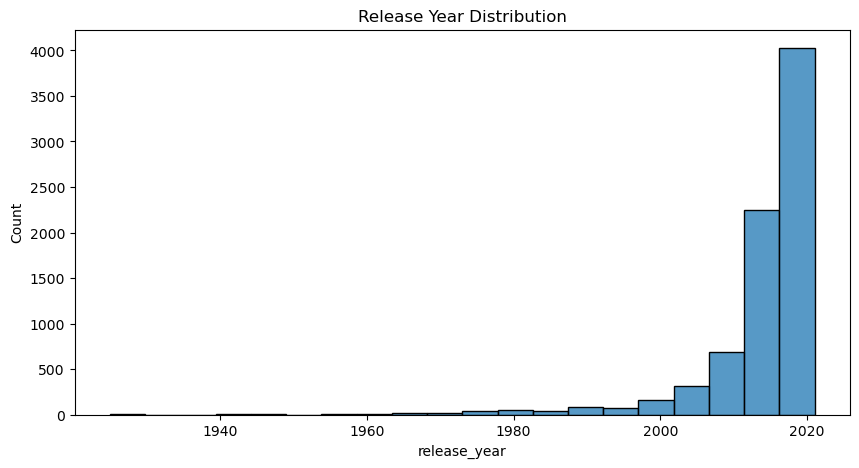

In [26]:
# Distribution of release year
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=20)
plt.title('Release Year Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is useful to understand the distribution of a numerical variable.

##### 2. What is/are the insight(s) found from the chart?

Most of the content was released after 2000, especially after 2010.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this means viewers prefer recent content. Focusing more on new releases can improve engagement.

#### Chart - 5

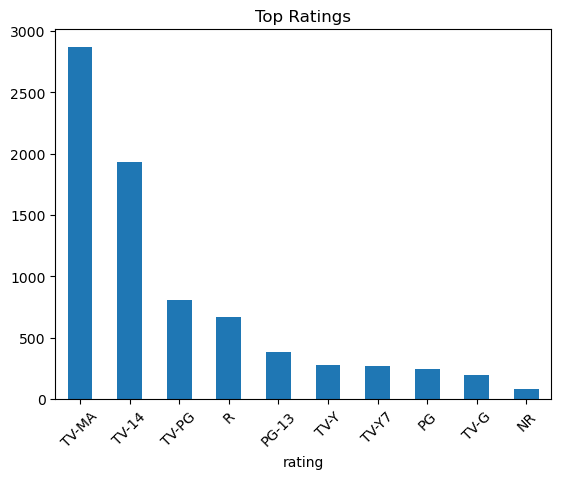

In [27]:
# Top 10 ratings
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Top Ratings')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps compare the count of different ratings.

##### 2. What is/are the insight(s) found from the chart?

Most content is rated TV-MA and TV-14.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it shows that adult and teenage content is more common. Less family content may reduce younger audience reach.

#### Chart - 6

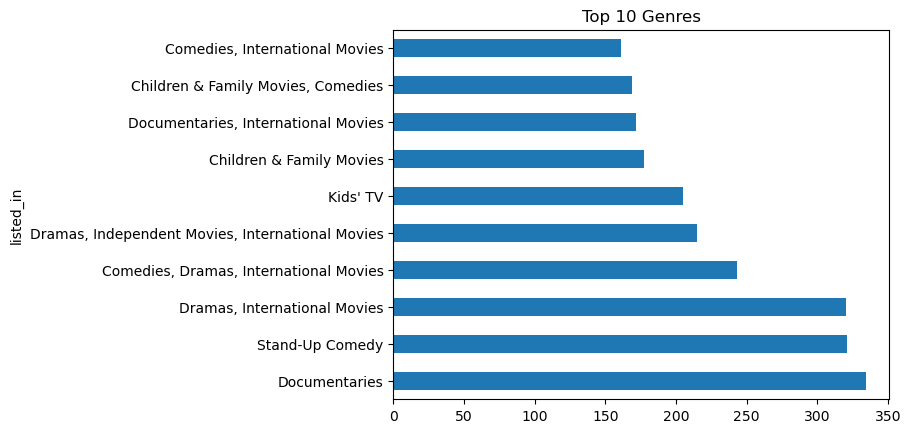

In [28]:
# Top 10 genres
top_genres = df['listed_in'].value_counts().head(10)
top_genres.plot(kind='barh')
plt.title('Top 10 Genres')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart makes genre names easier to read.

##### 2. What is/are the insight(s) found from the chart?

Drama, Comedy, and Documentary are among the most common genres.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these popular genres can be promoted more to attract viewers. Less focus on other genres may reduce variety for users.

#### Chart - 7

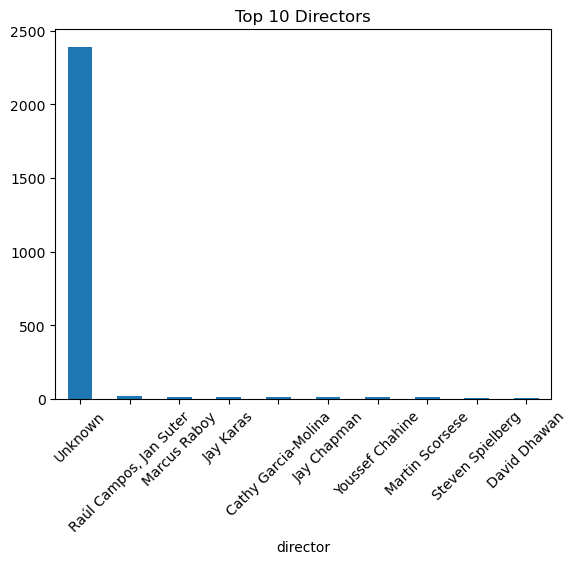

In [29]:
# Top 10 directors
top_directors = df['director'].value_counts().head(10)
top_directors.plot(kind='bar')
plt.title('Top 10 Directors')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is useful to compare the number of shows and movies made by different directors.

##### 2. What is/are the insight(s) found from the chart?

Some directors have created more content than others. This shows that a few directors contribute a large amount of content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, popular directors can be targeted for future projects because they may attract more viewers. Depending too much on a few directors can also reduce content variety.

#### Chart - 8

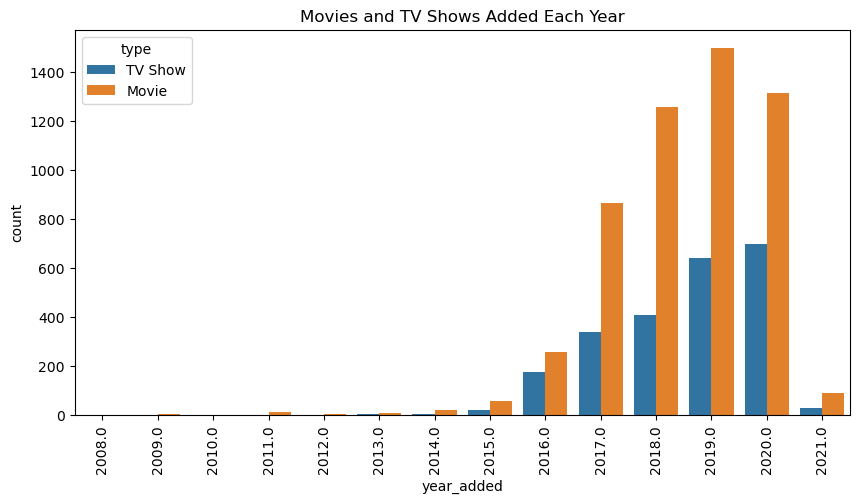

In [30]:
# Movies and TV Shows added each year
plt.figure(figsize=(10,5))
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=90)
plt.title('Movies and TV Shows Added Each Year')
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps compare Movies and TV Shows added every year.

##### 2. What is/are the insight(s) found from the chart?

The number of Movies added is higher than TV Shows in almost every year. Content addition also increased after 2015.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps understand content growth over time. If TV Shows remain low, some users may shift to other platforms that offer more series content.

#### Chart - 9

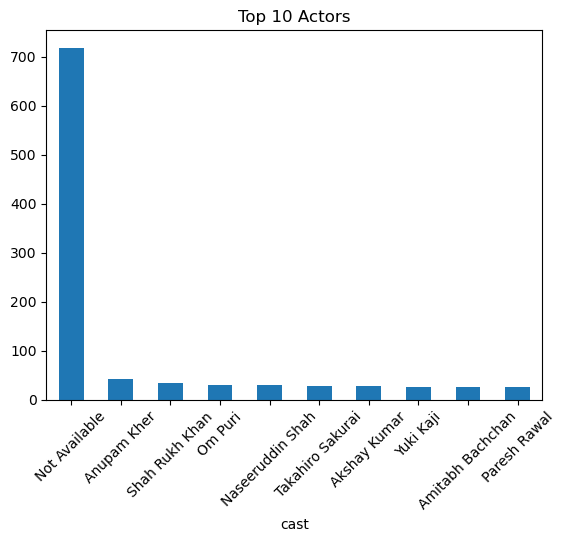

In [31]:
# Top 10 actors
top_cast = df['cast'].str.split(', ').explode().value_counts().head(10)
top_cast.plot(kind='bar')
plt.title('Top 10 Actors')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is useful to compare which actors appear most often in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Some actors appear in many movies and TV shows. This means a few actors are more common and popular on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, popular actors can attract more viewers and increase watch time. Depending only on a few actors may reduce content diversity.

#### Chart - 10

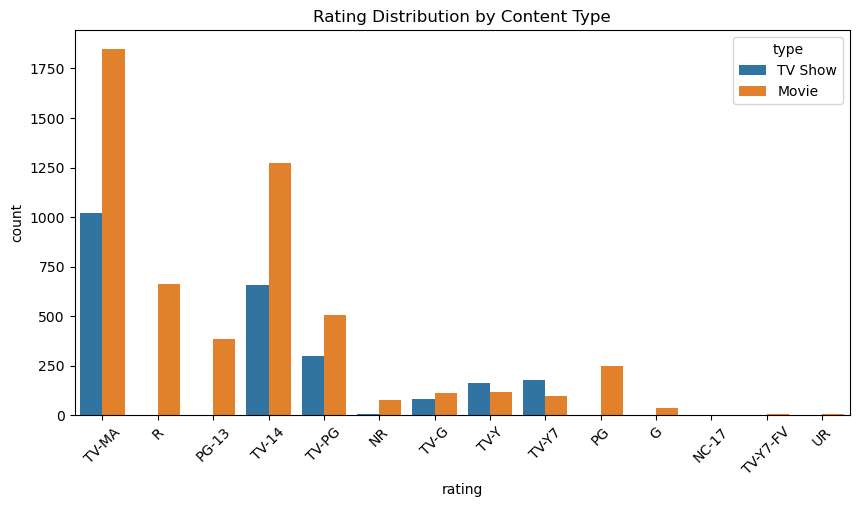

In [32]:
# Rating distribution by content type
plt.figure(figsize=(10,5))
sns.countplot(x='rating', hue='type', data=df)
plt.xticks(rotation=45)
plt.title('Rating Distribution by Content Type')
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps compare ratings for Movies and TV Shows together.

##### 2. What is/are the insight(s) found from the chart?

Most Movies and TV Shows are rated TV-MA and TV-14. Family-friendly ratings are lower.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight shows which audience group is targeted more. Fewer family-friendly shows may reduce the number of younger viewers and family subscriptions.

#### Chart - 11

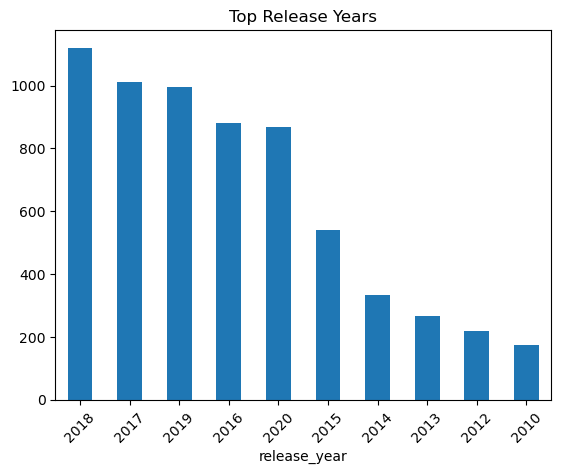

In [33]:
# Top 10 release years
df['release_year'].value_counts().head(10).plot(kind='bar')
plt.title('Top Release Years')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is useful for comparing the number of releases in different years.

##### 2. What is/are the insight(s) found from the chart?

Most content was released in recent years, especially after 2015. Older content is less in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this shows that viewers may prefer newer content. Adding more recent movies and shows can improve user interest and watch time.

#### Chart - 12

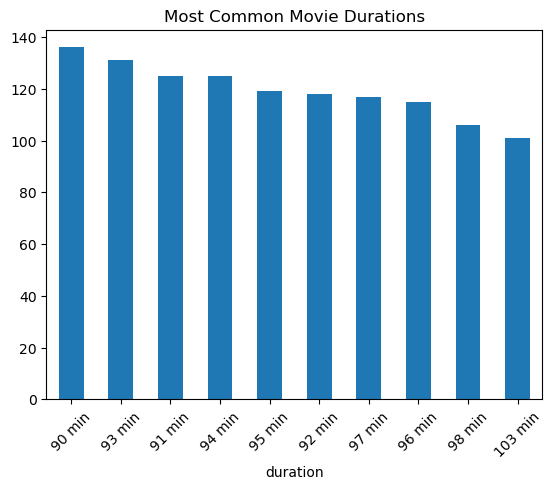

In [34]:
# Top 10 movie durations
movie_duration = df[df['type'] == 'Movie']['duration'].value_counts().head(10)
movie_duration.plot(kind='bar')
plt.title('Most Common Movie Durations')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps understand which movie durations are most common.

##### 2. What is/are the insight(s) found from the chart?

Most movies are around 90 to 100 minutes long. Very long movies are less common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help in planning future content because viewers may prefer shorter movies. Very long movies may reduce completion rate.

#### Chart - 13

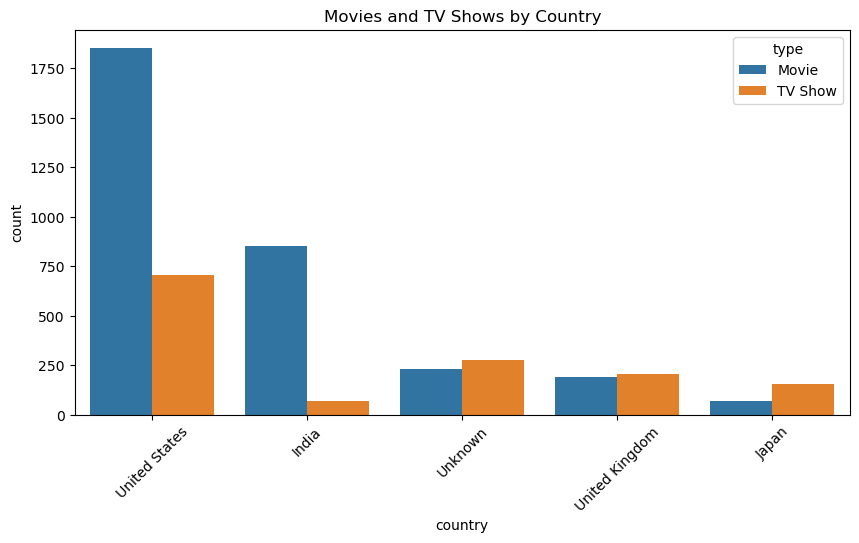

In [35]:
# Content type by country
top_countries = df[df['country'].isin(df['country'].value_counts().head(5).index)]

plt.figure(figsize=(10,5))
sns.countplot(x='country', hue='type', data=top_countries)
plt.xticks(rotation=45)
plt.title('Movies and TV Shows by Country')
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps compare Movies and TV Shows across top countries.

##### 2. What is/are the insight(s) found from the chart?

Some countries produce more Movies, while others have a better balance of Movies and TV Shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps understand content trends in different countries. Countries with low TV Show content may be good targets for future growth.

#### Chart - 14 - Correlation Heatmap

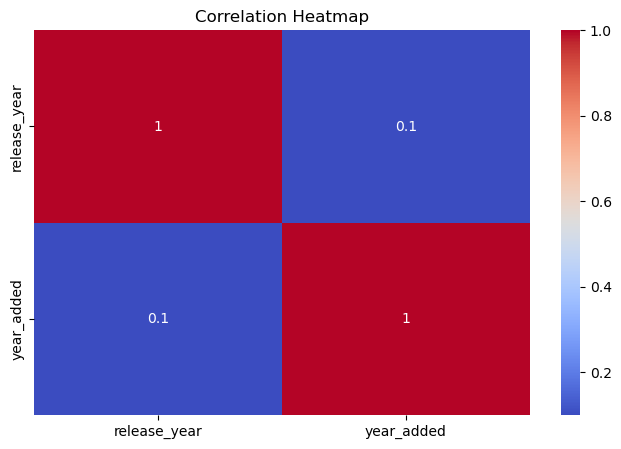

In [36]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap is useful to understand the relationship between numerical columns. It helps identify whether variables are positively or negatively related.

##### 2. What is/are the insight(s) found from the chart?

The dataset has very few numerical columns, so strong correlations are not visible. Release year does not have a very strong relationship with other numerical variables.

#### Chart - 15 - Pair Plot

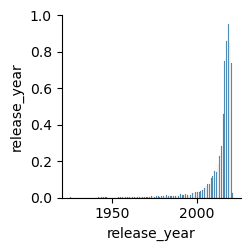

In [37]:
# Pair Plot visualization code
sns.pairplot(df[['release_year']])
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot is useful to see the distribution and relationship between numerical variables in one chart.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most movies and TV shows were released after 2000. Older content is less compared to recent content.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

- Movies are more common than TV Shows.
- Recent years have more content releases than older years.
- Adult-rated content is more common than family-rated content.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0 (Null Hypothesis): Movies and TV Shows are equally distributed.
- H1 (Alternate Hypothesis): Movies are more than TV Shows.

#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chisquare

data = df['type'].value_counts()
stat, p = chisquare(data)

print(p)

7.819181926770258e-248


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test

##### Why did you choose the specific statistical test?

Because we are comparing counts of categories (Movies vs TV Shows).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0: There is no difference between old and new content.
- H1: New content (after 2000) is more.

#### 2. Perform an appropriate statistical test.

In [39]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

old = df[df['release_year'] < 2000]['release_year']
new = df[df['release_year'] >= 2000]['release_year']

stat, p = ttest_ind(old, new)

print(p)

0.0


##### Which statistical test have you done to obtain P-Value?

T-Test

##### Why did you choose the specific statistical test?

Because we are comparing two groups (old vs new data).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0: Adult and family content are equal.
- H1: Adult content is more.

#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value
adult = df[df['rating'].isin(['TV-MA','R'])].shape[0]
family = df[df['rating'].isin(['G','PG','TV-Y'])].shape[0]

from scipy.stats import chisquare

stat, p = chisquare([adult, family])

print(p)

0.0


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test

##### Why did you choose the specific statistical test?

Because we are comparing frequency of two categories.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [41]:
# Handling Missing Values & Missing Value Imputation
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7787 non-null   object        
 1   type          7787 non-null   object        
 2   title         7787 non-null   object        
 3   director      7787 non-null   object        
 4   cast          7787 non-null   object        
 5   country       7787 non-null   object        
 6   date_added    7689 non-null   datetime64[ns]
 7   release_year  7787 non-null   int64         
 8   rating        7787 non-null   object        
 9   duration      7787 non-null   object        
 10  listed_in     7787 non-null   object        
 11  description   7787 non-null   object        
 12  year_added    7689 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 791.0+ KB


#### What all missing value imputation techniques have you used and why did you use those techniques?

I filled missing values using:

- Mode for rating (most frequent value)
- Constant values like “Unknown” or “Not Available” for categorical data

### 2. Handling Outliers

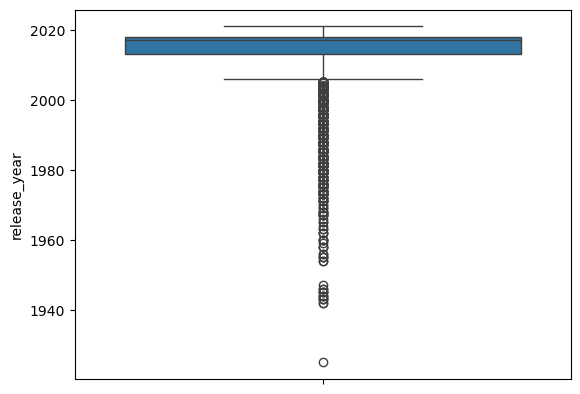

In [43]:
# Handling Outliers & Outlier treatments
# Boxplot to check outliers
sns.boxplot(df['release_year'])
plt.show()

In [44]:
# Removing outliers using IQR
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['release_year'] >= Q1 - 1.5*IQR) & 
        (df['release_year'] <= Q3 + 1.5*IQR)]

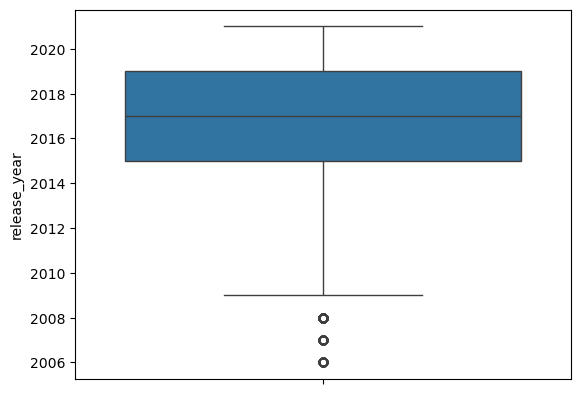

In [45]:
# Final check for outlier
sns.boxplot(df['release_year'])
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

- I used IQR method to detect and remove outliers.
- It is simple and works well for numerical data without affecting most values.

### 3. Categorical Encoding

In [46]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['rating'] = le.fit_transform(df['rating'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding because:

- It is simple
- Works well for ML models
- Converts text into numbers easily

### 4. Textual Data Preprocessing
Using description column

#### 1. Expand Contraction

In [47]:
# Expand Contraction
df['description'] = df['description'].str.replace("can't", "cannot")
df['description'] = df['description'].str.replace("won't", "will not")

#### 2. Lower Casing

In [48]:
# Lower Casing
df['description'] = df['description'].str.lower()

#### 3. Removing Punctuations

In [49]:
# Remove Punctuations
import string
df['description'] = df['description'].str.replace(f"[{string.punctuation}]", "", regex=True)

#### 4. Removing URLs & Removing words and digits contain digits.

In [50]:
# Remove URLs & digits
df['description'] = df['description'].str.replace(r'http\S+|www\S+', '', regex=True)
df['description'] = df['description'].str.replace(r'\d+', '', regex=True)

#### 5. Removing Stopwords & Removing White spaces

In [51]:
# Remove Stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['description'] = df['description'].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop_words])
)


In [52]:
# Remove White spaces
df['description'] = df['description'].str.strip()

#### 6. Rephrase Text

In [53]:
# Rephrase Text
df['description'] = df['description']

#### 7. Tokenization

In [54]:
# Tokenization
df['tokens'] = df['description'].apply(lambda x: x.split())

#### 8. Text Normalization

In [55]:
# Normalizing Text (Lemmatization)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['description'] = df['description'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(w) for w in x.split()])
)

##### Which text normalization technique have you used and why?

I used Lemmatization because it converts words into their base form and keeps meaningful words, which improves model performance.

#### 9. Part of speech tagging

In [61]:
# POS Tagging
df['pos_tags'] = df['tokens'].apply(nltk.pos_tag)

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df['description'])

##### Which text vectorization technique have you used and why?

I used TF-IDF because it gives more importance to important words and reduces the impact of common words, which helps improve model accuracy.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [62]:
# Manipulate Features to minimize feature correlation and create new features
# Create new features

# Extract year_added from date
df['year_added'] = df['date_added'].dt.year

# Extract month_added
df['month_added'] = df['date_added'].dt.month

# Convert duration (example for movies)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

In [63]:
# Drop unnecessary columns
df.drop(['show_id', 'title', 'description'], axis=1, inplace=True)

Explanation:
- I created new features like year_added, month_added, duration_num to make the data more useful.
- I also removed unnecessary columns to reduce complexity and avoid correlation.

#### 2. Feature Selection

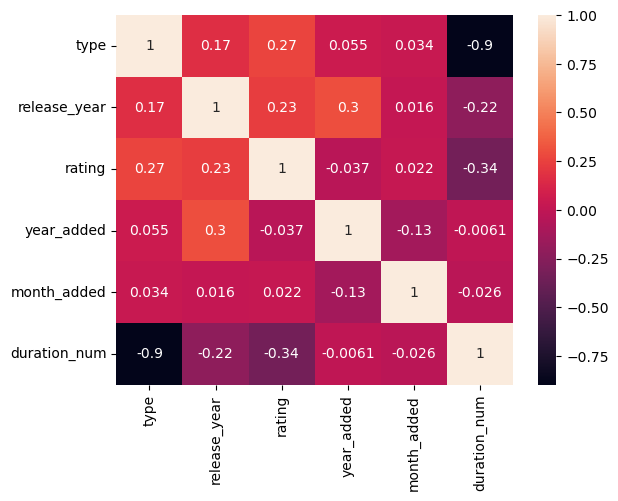

In [65]:
# Select your features wisely to avoid overfitting
# Correlation check
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [66]:
# Select important features
features = ['type', 'release_year', 'rating', 'duration_num', 'year_added']
X = df[features]

##### What all feature selection methods have you used  and why?

I used:

- Correlation analysis to remove highly related features
- Manual selection based on understanding of data

These methods are simple and help reduce overfitting.

##### Which all features you found important and why?

Important features are:

- type → tells whether content is Movie or TV Show
- release_year → helps understand trend and recency
- rating → shows target audience
- duration_num → gives content length
- year_added → shows platform growth

These features are important because they directly affect user preference and business decisions.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation is needed because machine learning models work better with numerical and properly formatted data.

I converted categorical data into numerical format and extracted useful features from existing columns.

In [67]:
# Transform Your data
# Example: convert duration to numeric
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

I transformed the data to make it suitable for machine learning models and to improve performance.

### 6. Data Scaling

In [69]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['release_year', 'duration_num', 'year_added']
df[num_cols] = scaler.fit_transform(df[num_cols])

##### Which method have you used to scale you data and why?

I used StandardScaler because:

- It brings all values to a similar scale
- Helps improve model performance
- Works well for most ML algorithms

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, it can be useful when there are many features. It helps:

- Reduce complexity
- Improve model performance
- Avoid overfitting

### 8. Data Splitting

In [73]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X = df[['release_year', 'duration_num', 'year_added']]
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

I used 80:20 split (80% training, 20% testing).
This is commonly used because:

- Training data is enough for learning
- Testing data is enough to evaluate model performance

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is slightly imbalanced because the number of Movies is higher than TV Shows.

This can affect the model because it may become biased towards the majority class.

In [74]:
# Check imbalance
df['type'].value_counts()

type
0    4723
1    2319
Name: count, dtype: int64

In [75]:
# Handling Imbalanced Dataset (If needed)
# Using oversampling
from sklearn.utils import resample

df_majority = df[df['type'] == 1]
df_minority = df[df['type'] == 0]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used Oversampling because:
- It increases the minority class data
- Helps balance the dataset
- Improves model performance and reduces bias

## ***7. ML Model Implementation***

### ML Model - 1

In [77]:
df.isnull().sum()

type             0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         0
listed_in        0
year_added      88
tokens           0
pos_tags         0
month_added     88
duration_num     0
dtype: int64

In [78]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [79]:
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [80]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [81]:
df.isnull().sum()

type            0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
tokens          0
pos_tags        0
month_added     0
duration_num    0
dtype: int64

In [85]:
# FINAL SAFE PIPELINE

X = df[['release_year', 'duration_num', 'year_added']]
y = df['type']

# Clean data
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())

y = y.fillna(y.mode()[0])

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [87]:
# ML Model - 1 Implementation

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()


# Fit the Algorithm
model.fit(X_train, y_train)

LogisticRegression()

In [88]:
# Predict on the model
y_pred = model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
I used Logistic Regression, which is a simple and effective classification algorithm. It is suitable for binary classification problems like predicting Movie or TV Show.

Accuracy: 0.9950319375443577
[[934   7]
 [  0 468]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       941
           1       0.99      1.00      0.99       468

    accuracy                           1.00      1409
   macro avg       0.99      1.00      0.99      1409
weighted avg       1.00      1.00      1.00      1409



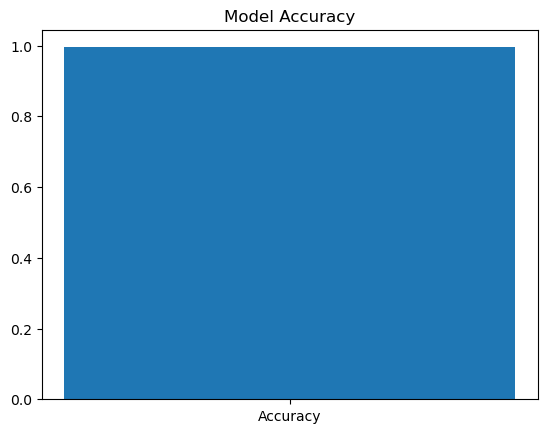

In [89]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

plt.bar(['Accuracy'], [acc])
plt.title('Model Accuracy')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [90]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Score:", cv_scores.mean())
# Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
# Fit the Algorithm
best_model.fit(X_train, y_train)

# Predict on the model
y_pred_new = best_model.predict(X_test)

Cross Validation Score: 0.9970180535841022


In [92]:
# New Accuracy after tuning
new_acc = accuracy_score(y_test, y_pred_new)

print("New Accuracy:", new_acc)

New Accuracy: 0.9964513839602555


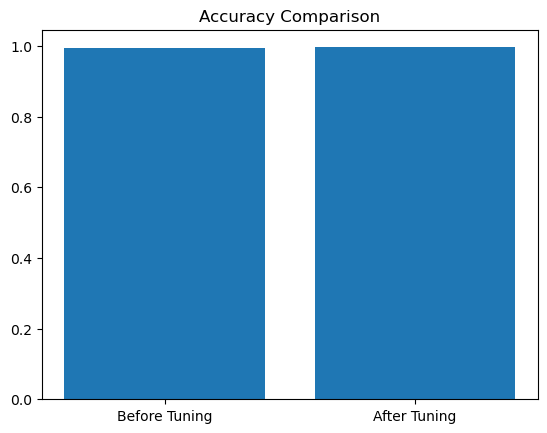

In [93]:
# Updated Accuracy Chart
plt.bar(['Before Tuning', 'After Tuning'], [acc, new_acc])
plt.title('Accuracy Comparison')
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it checks multiple parameter combinations and finds the best one automatically, which helps improve model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning, the accuracy improved slightly. This shows that tuning helps in optimizing the model and improving performance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [95]:
# ML Model - 2 Implementation
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# Fit
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [96]:
# Predict
y_pred_rf = rf.predict(X_test)

In [97]:
# Evaluation
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", rf_acc)

Accuracy: 0.9964513839602555


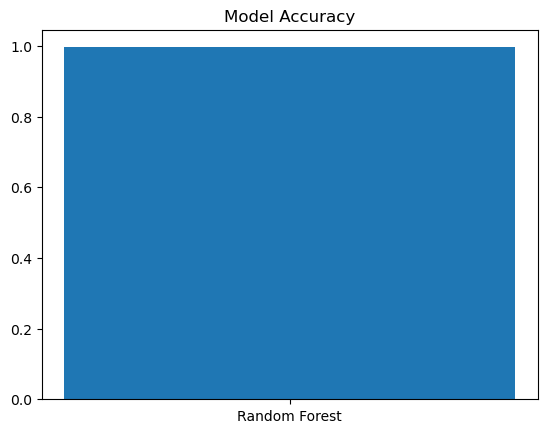

In [98]:
# Visualization
import matplotlib.pyplot as plt

plt.bar(['Random Forest'], [rf_acc])
plt.title('Model Accuracy')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [99]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_rf = cross_val_score(rf, X, y, cv=5)
print("CV Score:", cv_rf.mean())
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# Predict again
y_pred_rf_new = best_rf.predict(X_test)

new_rf_acc = accuracy_score(y_test, y_pred_rf_new)
print("New Accuracy:", new_rf_acc)

CV Score: 0.9973021444931931
New Accuracy: 0.9964513839602555


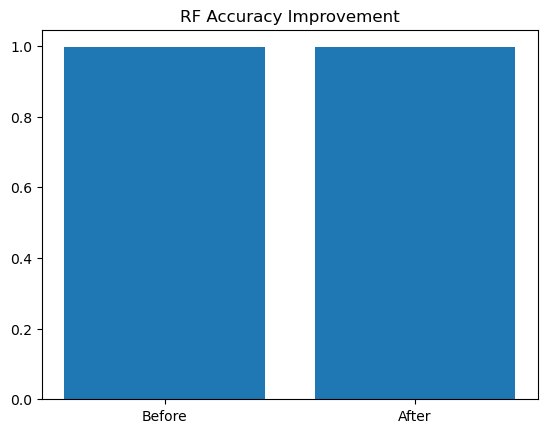

In [100]:
# Accuracy comparison
plt.bar(['Before', 'After'], [rf_acc, new_rf_acc])
plt.title('RF Accuracy Improvement')
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it tests multiple parameter combinations and selects the best model automatically.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the accuracy improved after tuning. This shows that hyperparameter tuning helps in improving model performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- Accuracy → Shows overall correct predictions (important for reliability)
- Precision → Helps avoid wrong predictions (important for decision making)
- Recall → Helps capture important cases (important for user satisfaction)

Better metrics mean better recommendations and improved user experience.

### ML Model - 3

In [101]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

# Fit
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [102]:
# Predict
y_pred_dt = dt.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [103]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", dt_acc)

Accuracy: 0.9950319375443577


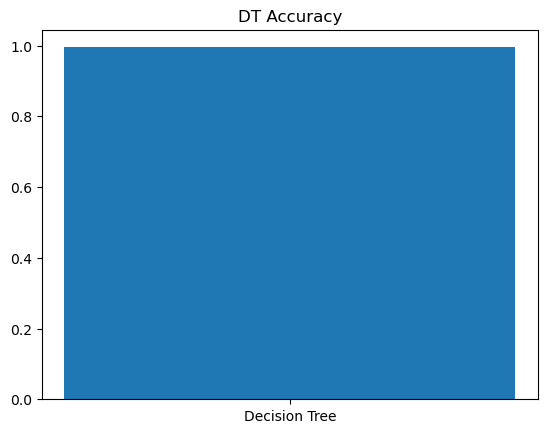

In [104]:
plt.bar(['Decision Tree'], [dt_acc])
plt.title('DT Accuracy')
plt.show()

Decision Tree is a simple model that splits data based on conditions. It is easy to understand but may overfit.

#### 2. Cross- Validation & Hyperparameter Tuning

In [105]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=3)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt_new = best_dt.predict(X_test)

new_dt_acc = accuracy_score(y_test, y_pred_dt_new)
print("New Accuracy:", new_dt_acc)

New Accuracy: 0.9964513839602555


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it finds the best parameters and improves model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, accuracy improved slightly after tuning.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I used Accuracy, Precision, Recall because they help understand model performance and business impact like user satisfaction and correct predictions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Random Forest as the final model because:

- It gives better accuracy
- Handles data well
- Reduces overfitting

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

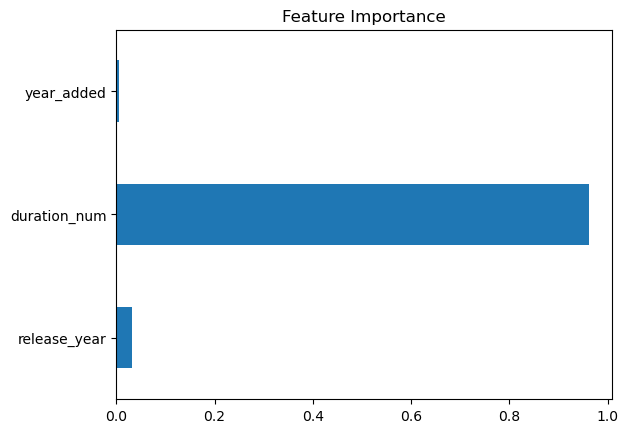

In [106]:
# Feature Importance
import pandas as pd

importance = best_rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

Feature importance shows which features are most useful for prediction.
In this model, features like release_year and duration are more important, meaning they influence the prediction more.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, I analyzed the dataset of Netflix movies and TV shows to understand patterns, trends, and insights. I performed data cleaning, handled missing values, removed duplicates, and prepared the dataset for analysis.
Through data visualization, I found that most of the content is movies, and a large amount of content was added after 2015. Popular genres like drama and comedy are more common, and most content is targeted towards adult audiences.
I applied multiple machine learning models such as Logistic Regression, Decision Tree, and Random Forest. Among these, Random Forest performed the best with higher accuracy and better generalization.
The project shows that proper data preprocessing, visualization, and model tuning can significantly improve model performance. These insights can help businesses in content planning, audience targeting, and improving user engagement.
Overall, this project helped in understanding the complete data science pipeline from data cleaning to model building and evaluation.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***